In [2]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

In [1]:
# Path
REFERENCE_PATH = "output_classification_cleaned.tif"   # ground truth (first raster)
PREDICTION_PATH = "Persistent_warehouse_2020_2025_landsat30m.tif" # another raster to compare with

# Class values in the rasters
# e.g. if warehouse=1, nonwarehouse=0
CLASS_VALUES  = [0, 1]
CLASS_LABELS  = ["nonwarehouse", "warehouse"]
NODATA_VALUE  = None 

In [3]:
# Checking that it loads correctly
def print_raster_info(path, label):
    with rasterio.open(path) as src:
        print(f"[{label}]")
        print(f"  CRS       : {src.crs}")
        print(f"  Resolution: {src.res}")
        print(f"  Shape     : {src.height} x {src.width}")
        print(f"  Bounds    : {src.bounds}")
        print(f"  Dtype     : {src.dtypes[0]}")
        print(f"  Nodata    : {src.nodata}")
        print("========================================")

print_raster_info(REFERENCE_PATH, "Raster 1")
print_raster_info(PREDICTION_PATH, "Raster 2")

[Raster 1]
  CRS       : EPSG:32616
  Resolution: (3.0, 3.0)
  Shape     : 20111 x 23138
  Bounds    : BoundingBox(left=541002.0, bottom=4376148.0, right=610416.0, top=4436481.0)
  Dtype     : uint8
  Nodata    : None
[Raster 2]
  CRS       : EPSG:4326
  Resolution: (0.00026949458523585707, 0.0002694945852358564)
  Shape     : 2304 x 3026
  Bounds    : BoundingBox(left=-86.52231456831267, bottom=39.4623616106717, right=-85.70682395338896, top=40.08327713505511)
  Dtype     : float32
  Nodata    : nan


In [4]:
def align_to_reference(ref_path, src_path, resampling=Resampling.nearest):
    """
    Reprojects and resamples src_path to match the grid of ref_path.
    Returns (ref_array, aligned_src_array).
    """
    with rasterio.open(ref_path) as ref:
        ref_array = ref.read(1).astype(np.float32)
        ref_nodata = ref.nodata
        ref_meta = ref.meta.copy()

    with rasterio.open(src_path) as src:
        aligned = np.empty((ref_meta['height'], ref_meta['width']), dtype=np.float32)

        reproject(source=rasterio.band(src, 1),destination=aligned,dst_transform=ref_meta['transform'],
                  dst_crs=ref_meta['crs'],resampling=resampling)

    return ref_array, aligned, ref_nodata


ref_arr, pred_arr, ref_nodata = align_to_reference(REFERENCE_PATH, PREDICTION_PATH)

In [6]:
# Mask nodata, and flatten to do confusion matrix
mask = np.ones(ref_arr.shape, dtype=bool)

if NODATA_VALUE is not None:
    mask &= (ref_arr != NODATA_VALUE)
    mask &= (pred_arr != NODATA_VALUE)

if ref_nodata is not None:
    mask &= (ref_arr != ref_nodata)

mask &= ~np.isnan(ref_arr)
mask &= ~np.isnan(pred_arr)

y_true = ref_arr[mask].astype(int)
y_pred = pred_arr[mask].astype(int)

print(f"Total valid pixels : {mask.sum():,}")
print(f"Skipped (nodata)   : {(~mask).sum():,}")

Total valid pixels : 465,223,587
Skipped (nodata)   : 104,731


In [7]:
cm = confusion_matrix(y_true, y_pred, labels=CLASS_VALUES)
overall_acc = accuracy_score(y_true, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nOverall Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, labels=CLASS_VALUES, target_names=CLASS_LABELS))

Confusion Matrix:
[[460463179    101051]
 [  1635056     10835]]

Overall Accuracy: 0.9898 (98.98%)

Classification Report:
              precision    recall  f1-score   support

nonwarehouse       0.99      1.00      1.00 460564230
   warehouse       0.02      0.01      0.01   1645891

   micro avg       0.99      1.00      0.99 462210121
   macro avg       0.51      0.50      0.50 462210121
weighted avg       0.99      1.00      0.99 462210121



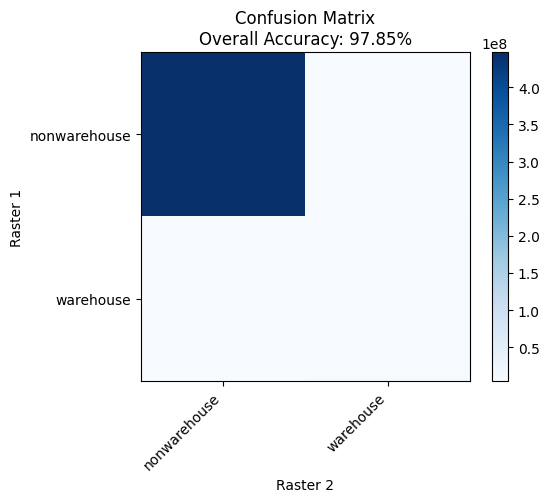

In [12]:
# plotting
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(CLASS_LABELS)))
ax.set_yticks(range(len(CLASS_LABELS)))
ax.set_xticklabels(CLASS_LABELS, rotation=45, ha='right')
ax.set_yticklabels(CLASS_LABELS)
ax.set_xlabel('Raster 2')
ax.set_ylabel('Raster 1')
ax.set_title(f'Confusion Matrix\nOverall Accuracy: {overall_acc*100:.2f}%')

plt.tight_layout()
plt.show()